# Notebook 02 – Centrality Analysis

PageRank, betweenness, degree top-15 tables, k-core decomposition.

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
from graph_utils import load_graph
from centrality import top_pagerank, top_betweenness, top_degree, kcore_stats

os.makedirs(os.path.join('..', 'figures'), exist_ok=True)

EDGE_FILE = os.path.join('..', 'data', 'com-dblp.ungraph.txt')
COMM_FILE = os.path.join('..', 'data', 'com-dblp.top5000.cmty.txt')
G, _ = load_graph(EDGE_FILE, COMM_FILE)
print(f'Graph loaded: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')

Graph loaded: 317,080 nodes, 1,049,866 edges


## 1. Degree Top-15

Top 15 by Degree:
     Node  Degree
1   38868     343
2   45479     296
3   57571     290
4    6737     269
5   72210     264
6   63861     244
7   96321     230
8   13884     227
9   11457     225
10  21759     221
11  98618     219
12  31470     218
13  46911     218
14  13451     215
15  19267     215


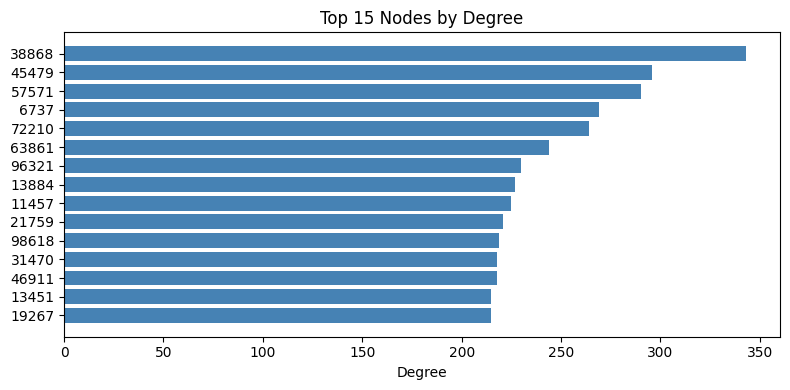

In [2]:
top_deg = top_degree(G, n=15)
df_deg = pd.DataFrame(top_deg, columns=['Node', 'Degree'])
df_deg.index += 1
print('Top 15 by Degree:')
print(df_deg.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh([str(n) for n, _ in top_deg[::-1]], [d for _, d in top_deg[::-1]], color='steelblue')
ax.set_xlabel('Degree')
ax.set_title('Top 15 Nodes by Degree')
plt.tight_layout()
plt.savefig(os.path.join('..', 'figures', 'top_degree.png'), dpi=150, bbox_inches='tight')
plt.show()

## 2. PageRank Top-15

Top 15 by PageRank:
     Node  PageRank
1   57571  0.000098
2    6737  0.000079
3   96321  0.000078
4    4799  0.000070
5   19267  0.000069
6   11323  0.000067
7   98618  0.000066
8   13830  0.000065
9   37335  0.000064
10  21759  0.000063
11  24947  0.000063
12   5945  0.000063
13   2419  0.000061
14  18917  0.000059
15  12110  0.000059


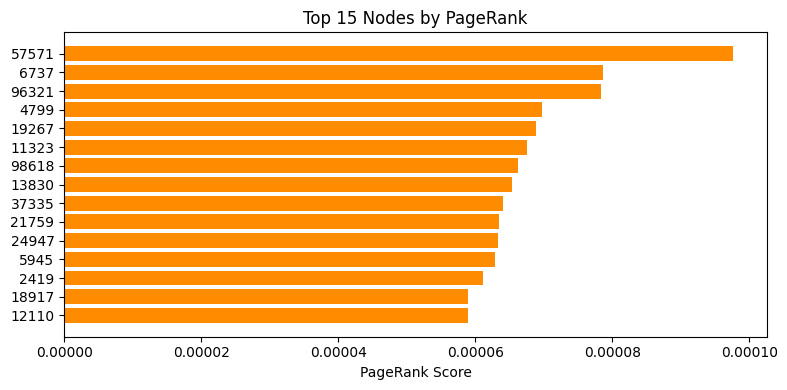

In [3]:
top_pr = top_pagerank(G, n=15)
df_pr = pd.DataFrame(top_pr, columns=['Node', 'PageRank'])
df_pr.index += 1
print('Top 15 by PageRank:')
print(df_pr.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh([str(n) for n, _ in top_pr[::-1]], [s for _, s in top_pr[::-1]], color='darkorange')
ax.set_xlabel('PageRank Score')
ax.set_title('Top 15 Nodes by PageRank')
plt.tight_layout()
plt.savefig(os.path.join('..', 'figures', 'top_pagerank.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Betweenness Top-15 (approximate, k=500 samples)

Top 15 by Betweenness:
      Node  Betweenness
1    57571     0.016831
2    11123     0.009550
3     4799     0.008835
4     6737     0.007531
5    19267     0.007385
6    98618     0.007160
7    96321     0.006964
8    38868     0.006838
9    37335     0.006668
10   16392     0.006383
11   28005     0.006273
12    3420     0.006126
13  180399     0.005604
14   21759     0.005294
15   33126     0.004983


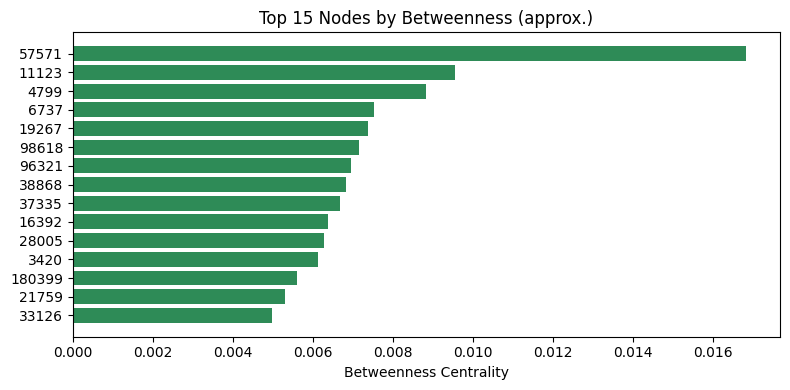

In [4]:
top_bc = top_betweenness(G, n=15, k=500)
df_bc = pd.DataFrame(top_bc, columns=['Node', 'Betweenness'])
df_bc.index += 1
print('Top 15 by Betweenness:')
print(df_bc.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh([str(n) for n, _ in top_bc[::-1]], [s for _, s in top_bc[::-1]], color='seagreen')
ax.set_xlabel('Betweenness Centrality')
ax.set_title('Top 15 Nodes by Betweenness (approx.)')
plt.tight_layout()
plt.savefig(os.path.join('..', 'figures', 'top_betweenness.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. K-Core Decomposition

Maximum core number: 113


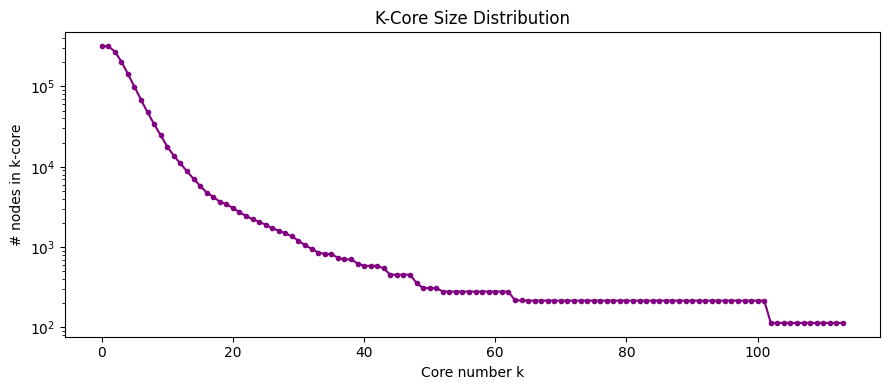

In [5]:
kc = kcore_stats(G)
print(f'Maximum core number: {kc["max_core"]}')

ks = sorted(kc['core_size_dist'].keys())
sizes = [kc['core_size_dist'][k] for k in ks]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ks, sizes, marker='o', markersize=3, linewidth=1.5, color='purple')
ax.set_xlabel('Core number k')
ax.set_ylabel('# nodes in k-core')
ax.set_title('K-Core Size Distribution')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig(os.path.join('..', 'figures', 'kcore_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Centrality Overlap – Nodes in Top-15 of Multiple Metrics

In [6]:
set_deg = set(n for n, _ in top_deg)
set_pr  = set(n for n, _ in top_pr)
set_bc  = set(n for n, _ in top_bc)

print('Nodes in top-15 of ALL three metrics:', set_deg & set_pr & set_bc)
print('Degree ∩ PageRank :', set_deg & set_pr)
print('Degree ∩ Betweenness:', set_deg & set_bc)
print('PageRank ∩ Betweenness:', set_pr & set_bc)

Nodes in top-15 of ALL three metrics: {96321, 19267, 57571, 6737, 98618, 21759}
Degree ∩ PageRank : {96321, 19267, 57571, 6737, 98618, 21759}
Degree ∩ Betweenness: {96321, 19267, 57571, 6737, 38868, 98618, 21759}
PageRank ∩ Betweenness: {96321, 19267, 57571, 6737, 4799, 37335, 98618, 21759}
